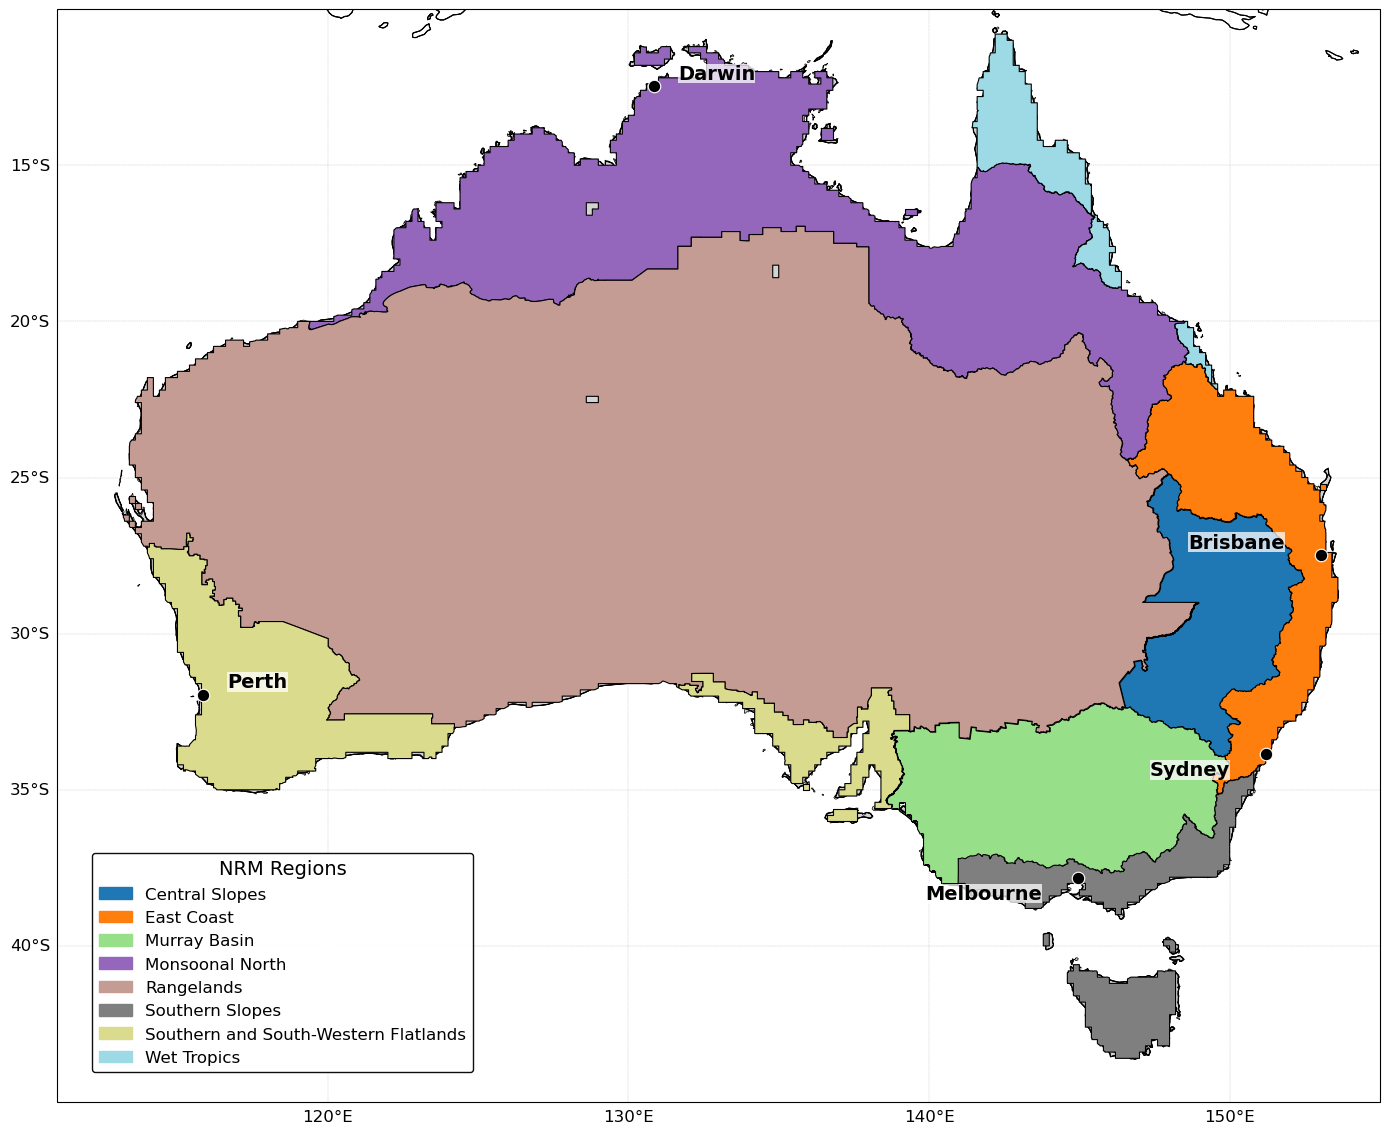

In [9]:
import xarray as xr
import geopandas as gpd
import regionmask
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

from pathlib import Path
from shapely.geometry import shape
from shapely.ops import unary_union

# ============================================================
# File paths
# ============================================================

mask_file = Path(
    "/scratch/dt6/xw9650/tmp/regridded/"
    "sftlf_AUS-18_ACCESS-ESM1-5_historical_r6i1p1f1_"
    "NSW-Government_NARCliM2-0-WRF412R3_v1-r1_fx.nc"
)

nrm_shapefile = (
    "/scratch/dt6/xw9650/tmp/reference_data/"
    "NRM_clusters/NRM_clusters.shp"
)

# ============================================================
# Load land mask
# ============================================================

ds_mask = xr.open_dataset(mask_file)

land_mask = ds_mask["sftlf"] > 50

# Detect coordinate names automatically
lat_name = [c for c in land_mask.coords if "lat" in c.lower()][0]
lon_name = [c for c in land_mask.coords if "lon" in c.lower()][0]

lats = land_mask[lat_name]
lons = land_mask[lon_name]

# ============================================================
# Load NRM regions
# ============================================================

nrm_gdf = gpd.read_file(nrm_shapefile)

nrm_gdf = (
    nrm_gdf[nrm_gdf.geometry.notnull()]
    .to_crs("EPSG:4326")
)
import rasterio.features
from rasterio.transform import Affine
from shapely.geometry import shape

# ============================================================
# Build polygon from land mask
# ============================================================

# Convert mask to integer
mask_np = land_mask.values.astype(np.uint8)

# Flip latitude dimension for raster orientation
mask_np_flip = np.flipud(mask_np)

# Grid spacing
lon_vals = lons.values
lat_vals = lats.values

dx = float(np.mean(np.diff(lon_vals)))
dy = float(np.mean(np.diff(lat_vals)))

# Raster transform
transform = Affine.translation(
    lon_vals.min() - dx / 2,
    lat_vals.max() + dy / 2
) * Affine.scale(dx, -dy)

# Extract polygons
mask_polygons = []

for geom, value in rasterio.features.shapes(
    mask_np_flip,
    mask=mask_np_flip.astype(bool),
    transform=transform,
):

    if value == 1:

        poly = shape(geom)

        if poly.is_valid:
            mask_polygons.append(poly)

# Merge polygons
land_geom = unary_union(mask_polygons)

# ============================================================
# Clip NRM regions to land-mask area
# ============================================================

aligned_gdf = nrm_gdf.copy()

aligned_gdf["geometry"] = aligned_gdf.geometry.intersection(
    land_geom
)

aligned_gdf = aligned_gdf[
    ~aligned_gdf.geometry.is_empty
]

# ============================================================
# Major Australian cities
# ============================================================

cities = {
    "Perth": (115.8605, -31.9505),
    "Darwin": (130.8456, -12.4634),
    "Brisbane": (153.0260, -27.4705),
    "Sydney": (151.2093, -33.8688),
    "Melbourne": (144.9631, -37.8136),
}

# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(14, 12))

ax = plt.axes(projection=ccrs.PlateCarree())

# ------------------------------------------------------------
# Background map
# ------------------------------------------------------------

ax.add_feature(
    cfeature.OCEAN,
    facecolor="white",
    zorder=0
)

# ax.add_feature(
#     cfeature.LAND,
#     facecolor="lightgrey",
#     zorder=0
# )


# ------------------------------------------------------------
# Background map
# ------------------------------------------------------------

ax.add_feature(
    cfeature.OCEAN,
    facecolor="white",
    zorder=0
)

# ============================================================
# Add Australia only (Natural Earth)
# ============================================================

from cartopy.io import shapereader

reader = shapereader.Reader(
    shapereader.natural_earth(
        resolution="10m",
        category="cultural",
        name="admin_0_countries"
    )
)

for country in reader.records():

    if country.attributes["NAME"] == "Australia":

        ax.add_geometries(
            [country.geometry],
            crs=ccrs.PlateCarree(),
            facecolor="lightgrey",
            edgecolor="black",
            linewidth=0.5,
            zorder=0,
        )

# Coastline
ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8,
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.8
)

ax.add_feature(
    cfeature.STATES,
    linewidth=0.4
)

# ------------------------------------------------------------
# Gridlines
# ------------------------------------------------------------

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="gray",
    alpha=0.5,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# ============================================================
# Plot clipped NRM regions
# ============================================================

cmap = plt.get_cmap(
    "tab20",
    len(aligned_gdf)
)

for idx, row in aligned_gdf.iterrows():

    aligned_gdf.iloc[[idx]].plot(
        ax=ax,
        color=cmap(idx),
        edgecolor="black",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )

# ============================================================
# Plot major cities
# ============================================================

# Manually tuned label offsets (degrees)
city_offsets = {
    "Perth":     (0.8,  0.4, "left"),
    "Darwin":    (0.8,  0.4, "left"),
    "Brisbane":  (-1.2, 0.4, "right"),   # move left (near east edge)
    "Sydney":    (-1.2, -0.5, "right"),  # move left/down
    "Melbourne": (-1.2, -0.5, "right"),  # move left/down
}

for city, (lon, lat) in cities.items():

    ax.plot(
        lon,
        lat,
        marker="o",
        markersize=9,
        color="black",
        markeredgecolor="white",
        markeredgewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10,
    )

    dx, dy, ha = city_offsets[city]

    ax.text(
        lon + dx,
        lat + dy,
        city,
        fontsize=14,          # larger font
        fontweight="bold",
        ha=ha,
        va="center",
        transform=ccrs.PlateCarree(),
        zorder=11,
        clip_on=True,         # prevents text extending outside axes
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=0.2,
        ),
    )
# ============================================================
# Inset legend
# ============================================================

patches = []

for i, region_name in enumerate(aligned_gdf["label"]):

    patches.append(
        mpatches.Patch(
            color=cmap(i),
            label=region_name
        )
    )

legend = ax.legend(
    handles=patches,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    fontsize=12,
    title="NRM Regions",
    title_fontsize=14,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="black",
)

# ============================================================
# Domain extent
# ============================================================

# ax.set_extent([
#     float(lons.min()),
#     float(lons.max()),
#     float(lats.min()),
#     float(lats.max())
# ], crs=ccrs.PlateCarree())

ax.set_extent(
    [111, 155, -45, -10],   # [west, east, south, north]
    crs=ccrs.PlateCarree()
)

# ============================================================
# Final formatting
# ============================================================

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================

outdir = Path("/scratch/dt6/xw9650/tmp/maps_and_graphs")
outdir.mkdir(parents=True, exist_ok=True)

outfile = outdir / "NARCliM2_NRM_map.png"

plt.savefig(
    outfile,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)


plt.show()